# Maximum Favorable/Adverse Excursion (MFE/MAE) Analysis

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.2 - Label Engineering

## Purpose

This notebook provides **empirical justification** for triple-barrier parameter
choices. Rather than picking arbitrary barrier widths, we analyze actual price
excursions to determine appropriate thresholds.

## Key Questions Answered

1. How far do prices typically move in our favor before reversing?
2. How far do prices move against us before recovering?
3. How do these distributions differ by asset class and volatility regime?
4. What barrier widths capture meaningful price moves without excessive stops?

## MFE/MAE Definitions

Maximum Favorable Excursion (MFE) and Maximum Adverse Excursion (MAE) were
introduced by John Sweeney in *Campaign Trading* (1996) to analyze trade
management. For a **long** entry at time $t$ with holding period $H$:

$$\text{MFE}(t) = \max_{u \in [t, t+H]} \left( \frac{\text{high}(u)}{\text{entry}(t)} - 1 \right)$$

$$\text{MAE}(t) = \max_{u \in [t, t+H]} \left( 1 - \frac{\text{low}(u)}{\text{entry}(t)} \right)$$

**Note**: Both MFE and MAE are non-negative by definition. For **short** positions,
the definitions reverse: MFE uses lows (favorable moves down) and MAE uses highs
(adverse moves up).

## Data Coverage

- **ETF Universe** (daily): SPY as representative equity exposure
- **Crypto Premium** (hourly): BTC for high-volatility comparison
- **CME Futures** (daily): ES for institutional context

## Prerequisites

- `03_label_methods` — defines the triple-barrier label whose parameters
  this notebook empirically justifies.
- Familiarity with OHLCV bar data and ATR (true range with Wilder smoothing).
- Polars `max_horizontal` / `min_horizontal` and forward-shifted columns.

In [1]:
"""Maximum Favorable and Adverse Excursion — ATR-normalized trade path analysis for barrier calibration."""

from __future__ import annotations

import json
import warnings
from datetime import UTC, datetime
from typing import Literal

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.excursion import analyze_excursions
from ml4t.engineer.config.labeling import LabelingConfig
from ml4t.engineer.features.volatility import atr as library_atr
from ml4t.engineer.labeling import triple_barrier_labels
from plotly.subplots import make_subplots

from data import load_cme_futures, load_crypto_perps, load_etfs
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS  # activates the ml4t Plotly template + house palette

warnings.filterwarnings("ignore")

/home/stefan/ml4t/code/.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [2]:
SEED = 42
ETF_START_DATE = "2015-01-01"
CRYPTO_START_DATE = "2021-01-01"
FUTURES_START_DATE = "2015-01-01"
SAVE_OUTPUT = True

In [3]:
# Output directory for JSON export
CHAPTER_DIR = get_chapter_dir(7)
set_global_seeds(SEED)
OUTPUT_DIR = CHAPTER_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Vectorized MFE/MAE Computation

We use Polars' `max_horizontal` and `min_horizontal` functions to compute
forward-looking extremes without Python loops. This approach builds $H+1$ shifted
columns, resulting in $O(n \times H)$ work and memory. While vectorized (no Python
loops), memory scales with horizon. For very large horizons, consider the
reverse-rolling approach: `high.reverse().rolling_max(H+1).reverse()`.

In [4]:
def compute_mfe_mae(
    prices: pl.DataFrame,
    timestamp_col: str,
    close_col: str,
    horizon_bars: int,
    high_col: str = "high",
    low_col: str = "low",
    side: Literal[1, -1] = 1,
    unit: Literal["pct", "decimal"] = "pct",
) -> pl.DataFrame:
    """
    Compute maximum favorable excursion (MFE) and maximum adverse excursion (MAE).

    Definitions are for a long position when side=1:
    - MFE(t) = max_{u in [t, t+h]} (high(u)/entry(t) - 1)
    - MAE(t) = max_{u in [t, t+h]} (1 - low(u)/entry(t))

    For short positions (side=-1), favorable and adverse are swapped.

    Results are clipped at 0 to reflect the standard non-negative excursion notion.

    Parameters
    ----------
    prices : pl.DataFrame
        OHLCV data with timestamp, high, low, close columns
    timestamp_col : str
        Name of timestamp column
    close_col : str
        Name of close price column (used as entry price)
    horizon_bars : int
        Number of bars in the forward window
    high_col : str
        Name of high price column (default: "high")
    low_col : str
        Name of low price column (default: "low")
    side : {1, -1}
        Trade direction: 1 for long, -1 for short
    unit : {"pct", "decimal"}
        Output format: "pct" for percentage, "decimal" for raw

    Returns
    -------
    pl.DataFrame
        Columns: timestamp, mfe_pct (or mfe), mae_pct (or mae), final_return_pct (or final_return)
    """
    if horizon_bars <= 0:
        raise ValueError("horizon_bars must be positive")
    if side not in (1, -1):
        raise ValueError("side must be 1 (long) or -1 (short)")

    df = prices.sort(timestamp_col)

    # Use close if high/low not available
    effective_high_col = high_col if high_col in df.columns else close_col
    effective_low_col = low_col if low_col in df.columns else close_col

    # Compute forward-looking max high and min low using horizontal operations
    # This is vectorized and efficient for reasonable horizon sizes
    forward_high = pl.max_horizontal(
        [pl.col(effective_high_col).shift(-k) for k in range(horizon_bars + 1)]
    )
    forward_low = pl.min_horizontal(
        [pl.col(effective_low_col).shift(-k) for k in range(horizon_bars + 1)]
    )

    entry = pl.col(close_col)
    exit_ = pl.col(close_col).shift(-horizon_bars)

    # Long position formulas
    long_mfe = (forward_high / entry - 1.0).clip(lower_bound=0.0)
    long_mae = (1.0 - forward_low / entry).clip(lower_bound=0.0)
    long_final = exit_ / entry - 1.0

    # Short position formulas (swap favorable/adverse)
    short_mfe = (1.0 - forward_low / entry).clip(lower_bound=0.0)
    short_mae = (forward_high / entry - 1.0).clip(lower_bound=0.0)
    short_final = 1.0 - exit_ / entry

    # Select based on side
    mfe = pl.when(pl.lit(side) == 1).then(long_mfe).otherwise(short_mfe)
    mae = pl.when(pl.lit(side) == 1).then(long_mae).otherwise(short_mae)
    final_ret = pl.when(pl.lit(side) == 1).then(long_final).otherwise(short_final)

    scale = 100.0 if unit == "pct" else 1.0

    # Output column names based on unit
    mfe_name = "mfe_pct" if unit == "pct" else "mfe"
    mae_name = "mae_pct" if unit == "pct" else "mae"
    final_name = "final_return_pct" if unit == "pct" else "final_return"

    out = df.select(
        [
            pl.col(timestamp_col).alias("timestamp"),
            (mfe * scale).alias(mfe_name),
            (mae * scale).alias(mae_name),
            (final_ret * scale).alias(final_name),
        ]
    ).drop_nulls()

    return out

## 2. ATR Computation

**True Range** (accounts for gaps) with Wilder's smoothing:

$$TR_t = \max\left( H_t - L_t, |H_t - C_{t-1}|, |L_t - C_{t-1}| \right)$$

$$ATR_t = \frac{n-1}{n} ATR_{t-1} + \frac{1}{n} TR_t$$

The Wilder smoothing is equivalent to an EMA with $\alpha = 1/n$.

In [5]:
def compute_atr(
    prices: pl.DataFrame,
    timestamp_col: str,
    high_col: str = "high",
    low_col: str = "low",
    close_col: str = "close",
    period: int = 14,
    unit: Literal["price", "pct"] = "pct",
) -> pl.DataFrame:
    """
    Compute ATR using true range with Wilder-style smoothing.

    Parameters
    ----------
    prices : pl.DataFrame
        OHLCV data
    timestamp_col : str
        Name of timestamp column
    high_col, low_col, close_col : str
        Column names for OHLC data
    period : int
        Smoothing period (default: 14, Wilder's original)
    unit : {"price", "pct"}
        Output format: "price" for absolute ATR, "pct" for ATR/close * 100

    Returns
    -------
    pl.DataFrame
        Columns: timestamp, atr, and optionally atr_pct
    """
    if period <= 0:
        raise ValueError("period must be positive")

    df = prices.sort(timestamp_col)

    # True Range: max of (H-L, |H-prev_close|, |L-prev_close|)
    prev_close = pl.col(close_col).shift(1)
    tr = pl.max_horizontal(
        [
            (pl.col(high_col) - pl.col(low_col)).abs(),
            (pl.col(high_col) - prev_close).abs(),
            (pl.col(low_col) - prev_close).abs(),
        ]
    ).alias("true_range")

    # Wilder smoothing: EMA with alpha = 1/period
    atr = tr.ewm_mean(alpha=1.0 / period, adjust=False).alias("atr")

    out = df.with_columns([tr, atr]).select(
        [pl.col(timestamp_col).alias("timestamp"), pl.col("atr"), pl.col(close_col)]
    )

    if unit == "pct":
        out = out.with_columns([(pl.col("atr") / pl.col(close_col) * 100.0).alias("atr_pct")])

    return out.drop_nulls().select(["timestamp", "atr"] + (["atr_pct"] if unit == "pct" else []))

In [6]:
def compute_percentiles(series: pl.Series, percentiles: list[float]) -> dict[float, float]:
    """Compute percentiles for a series."""
    return {p: float(series.quantile(p / 100)) for p in percentiles}

### 2.1 Library ATR: ml4t-engineer

The manual `compute_atr()` above teaches Wilder's smoothing. `ml4t-engineer`
provides the same algorithm with edge-case handling and panel data support —
a modern Python alternative to TA-Lib's `ATR()` function.

## 3. ETF Analysis (Daily)

We start with SPY as the representative low-volatility daily asset.

In [7]:
try:
    etfs = load_etfs()

    # Focus on SPY
    spy = etfs.filter(pl.col("symbol") == "SPY").sort("timestamp")

    # Filter date range
    spy = spy.filter(
        pl.col("timestamp")
        >= pl.lit(datetime.strptime(ETF_START_DATE, "%Y-%m-%d")).cast(spy["timestamp"].dtype)
    )

    print(f"SPY daily data: {len(spy):,} bars")
    print(f"Date range: {spy['timestamp'].min()} to {spy['timestamp'].max()}")

except Exception as e:
    print(f"ETF data not found - skipping: {e}")
    spy = None

SPY daily data: 2,766 bars
Date range: 2015-01-02 to 2025-12-31


### MFE/MAE computation (21-day horizon)

In [8]:
spy_mfe_mae = None
spy_atr = None

if spy is not None:
    etf_horizon = 21  # trading days
    spy_mfe_mae = compute_mfe_mae(spy, "timestamp", "close", etf_horizon, unit="pct", side=1)

    print(f"SPY MFE/MAE Statistics (21d horizon, n={len(spy_mfe_mae):,}):")
    print(
        f"  MFE mean: {spy_mfe_mae['mfe_pct'].mean():.2f}%  median: {spy_mfe_mae['mfe_pct'].median():.2f}%"
    )
    print(
        f"  MAE mean: {spy_mfe_mae['mae_pct'].mean():.2f}%  median: {spy_mfe_mae['mae_pct'].median():.2f}%"
    )

    # Percentiles for barrier selection
    mfe_pctls = compute_percentiles(spy_mfe_mae["mfe_pct"], [25, 50, 75, 90, 95])
    mae_pctls = compute_percentiles(spy_mfe_mae["mae_pct"], [25, 50, 75, 90, 95])

    print(f"\nMFE Percentiles: {mfe_pctls}")
    print(f"MAE Percentiles: {mae_pctls}")

SPY MFE/MAE Statistics (21d horizon, n=2,745):
  MFE mean: 3.50%  median: 3.06%
  MAE mean: 3.28%  median: 2.05%

MFE Percentiles: {25: 1.650834798888523, 50: 3.064195656996316, 75: 4.6360580506486615, 90: 6.513815723616401, 95: 8.245733186698345}
MAE Percentiles: {25: 0.935403375078947, 50: 2.0455031992095085, 75: 4.235810771059456, 90: 7.822991546922142, 95: 10.683733158263653}


### ATR comparison: manual vs library

In [9]:
if spy is not None:
    spy_atr = compute_atr(spy, "timestamp", period=14, unit="pct")
    avg_atr = float(spy_atr["atr_pct"].mean())
    print(f"SPY 14-day ATR: {avg_atr:.2f}% (average)")
    print(f"Suggested starting point: TP=2xATR ({avg_atr * 2:.2f}%), SL=1xATR ({avg_atr:.2f}%)")

    # Library ATR comparison
    lib_atr_values = library_atr(
        spy["high"].to_numpy(),
        spy["low"].to_numpy(),
        spy["close"].to_numpy(),
        period=14,
    )
    lib_atr_avg = float(np.nanmean(lib_atr_values / spy["close"].to_numpy() * 100))
    print(f"  Library ATR (ml4t-engineer): {lib_atr_avg:.2f}%")
    print(f"  Difference: {abs(avg_atr - lib_atr_avg):.4f}pp")

SPY 14-day ATR: 1.26% (average)
Suggested starting point: TP=2xATR (2.51%), SL=1xATR (1.26%)
  Library ATR (ml4t-engineer): 1.26%
  Difference: 0.0004pp


### ETF MFE/MAE Distribution

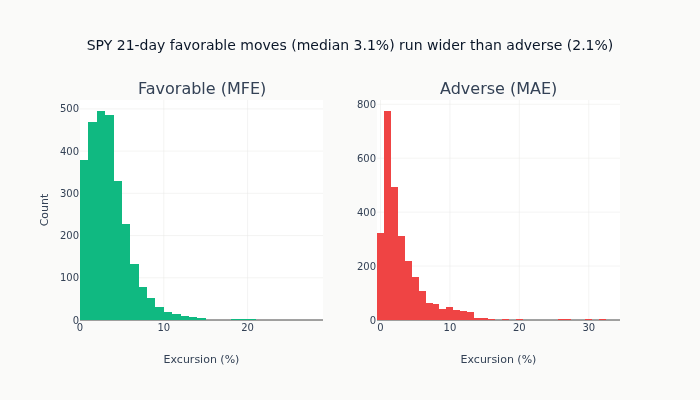

In [10]:
if spy_mfe_mae is not None:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Favorable (MFE)", "Adverse (MAE)"],
    )

    # MFE histogram
    fig.add_trace(
        go.Histogram(
            x=spy_mfe_mae["mfe_pct"].to_numpy(),
            nbinsx=50,
            name="MFE",
            marker_color=COLORS["positive"],
        ),
        row=1,
        col=1,
    )

    # MAE histogram
    fig.add_trace(
        go.Histogram(
            x=spy_mfe_mae["mae_pct"].to_numpy(),
            nbinsx=50,
            name="MAE",
            marker_color=COLORS["negative"],
        ),
        row=1,
        col=2,
    )

    fig.update_layout(
        title=f"SPY {etf_horizon}-day favorable moves (median 3.1%) run wider than adverse (2.1%)",
        showlegend=False,
        height=400,
    )
    fig.update_xaxes(title_text="Excursion (%)", row=1, col=1)
    fig.update_xaxes(title_text="Excursion (%)", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=1)

    fig.show()

## 4. Crypto Analysis (Hourly)

Crypto exhibits higher volatility, requiring wider barriers.

In [11]:
try:
    crypto = load_crypto_perps()

    # Focus on BTC for analysis
    btc = crypto.filter(pl.col("symbol") == "BTCUSDT").sort("timestamp")

    # Filter to recent data (cast literal to match column dtype)
    btc = btc.filter(
        pl.col("timestamp")
        >= pl.lit(datetime.strptime(CRYPTO_START_DATE, "%Y-%m-%d").replace(tzinfo=UTC)).cast(
            btc["timestamp"].dtype
        )
    )

    print(f"BTC hourly data: {len(btc):,} bars")
    print(f"Date range: {btc['timestamp'].min()} to {btc['timestamp'].max()}")

    # Compute MFE/MAE for 8-hour horizon (matches funding rate cycle)
    crypto_horizon = 8  # hours
    btc_mfe_mae = compute_mfe_mae(btc, "timestamp", "close", crypto_horizon, unit="pct", side=1)

    # Summary statistics
    print(f"\nBTC MFE/MAE Statistics (8h horizon, n={len(btc_mfe_mae):,}):")
    print(f"  MFE mean: {btc_mfe_mae['mfe_pct'].mean():.2f}%")
    print(f"  MFE median: {btc_mfe_mae['mfe_pct'].median():.2f}%")
    print(f"  MAE mean: {btc_mfe_mae['mae_pct'].mean():.2f}%")
    print(f"  MAE median: {btc_mfe_mae['mae_pct'].median():.2f}%")

    # Percentiles for barrier selection
    btc_mfe_pctls = compute_percentiles(btc_mfe_mae["mfe_pct"], [25, 50, 75, 90, 95])
    btc_mae_pctls = compute_percentiles(btc_mfe_mae["mae_pct"], [25, 50, 75, 90, 95])

    print(f"\nMFE Percentiles: {btc_mfe_pctls}")
    print(f"MAE Percentiles: {btc_mae_pctls}")

except Exception as e:
    print(f"Crypto data not found - skipping: {e}")
    btc_mfe_mae = None

BTC hourly data: 43,824 bars
Date range: 2021-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00

BTC MFE/MAE Statistics (8h horizon, n=43,816):
  MFE mean: 1.34%
  MFE median: 0.90%
  MAE mean: 1.40%
  MAE median: 0.91%

MFE Percentiles: {25: 0.46267360746989894, 50: 0.9003254631044344, 75: 1.7050098982684725, 90: 2.9337565279640376, 95: 3.931755527552827}
MAE Percentiles: {25: 0.468027465084786, 50: 0.914401724838354, 75: 1.7387448922121962, 90: 3.0309648647731224, 95: 4.158650640193207}


### Crypto MFE/MAE Distribution

In [12]:
if btc_mfe_mae is not None:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Favorable (MFE)", "Adverse (MAE)"],
    )

    # MFE histogram
    fig.add_trace(
        go.Histogram(
            x=btc_mfe_mae["mfe_pct"].to_numpy(),
            nbinsx=50,
            name="MFE",
            marker_color=COLORS["positive"],
        ),
        row=1,
        col=1,
    )

    # MAE histogram
    fig.add_trace(
        go.Histogram(
            x=btc_mfe_mae["mae_pct"].to_numpy(),
            nbinsx=50,
            name="MAE",
            marker_color=COLORS["negative"],
        ),
        row=1,
        col=2,
    )

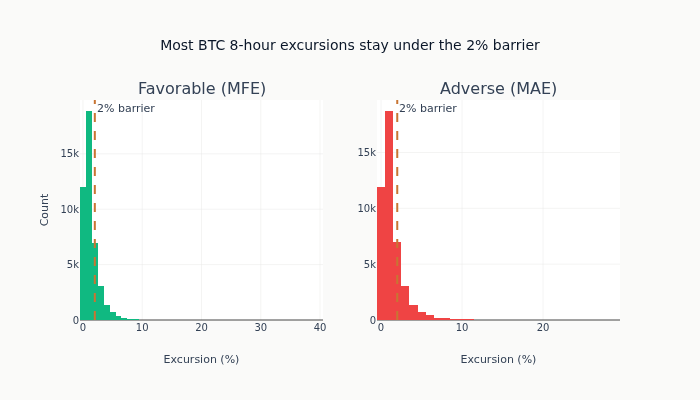

In [13]:
if btc_mfe_mae is not None:
    # Add barrier reference lines (2% from typical crypto settings)
    fig.add_vline(
        x=2.0,
        line_dash="dash",
        line_color=COLORS["copper"],
        row=1,
        col=1,
        annotation_text="2% barrier",
    )
    fig.add_vline(
        x=2.0,
        line_dash="dash",
        line_color=COLORS["copper"],
        row=1,
        col=2,
        annotation_text="2% barrier",
    )

    fig.update_layout(
        title=f"Most BTC {crypto_horizon}-hour excursions stay under the 2% barrier",
        showlegend=False,
        height=400,
    )
    fig.update_xaxes(title_text="Excursion (%)", row=1, col=1)
    fig.update_xaxes(title_text="Excursion (%)", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=1)

    fig.show()

## 5. Futures Analysis (Daily)

Futures have institutional flow and roll considerations.

In [14]:
try:
    es = load_cme_futures(products=["ES"])

    # Normalize timestamp column (daily data uses session_date)
    if "session_date" in es.columns:
        es = es.rename({"session_date": "timestamp"})
    elif "ts_event" in es.columns:
        es = es.rename({"ts_event": "timestamp"})
    elif "date" in es.columns:
        es = es.rename({"date": "timestamp"})
    es = es.sort("timestamp")

    # Filter date range (cast literal to match column dtype)
    es = es.filter(
        pl.col("timestamp")
        >= pl.lit(datetime.strptime(FUTURES_START_DATE, "%Y-%m-%d").replace(tzinfo=UTC)).cast(
            es["timestamp"].dtype
        )
    )

    print(f"ES futures data: {len(es):,} bars")
    print(f"Date range: {es['timestamp'].min()} to {es['timestamp'].max()}")

    # Compute MFE/MAE for 21-day horizon. Excursions ride the roll-adjusted
    # series (adj_*) so roll gaps don't register as favorable/adverse moves.
    futures_horizon = 21
    es_mfe_mae = compute_mfe_mae(
        es,
        "timestamp",
        "adj_close",
        futures_horizon,
        high_col="adj_high",
        low_col="adj_low",
        unit="pct",
        side=1,
    )

    # Summary statistics
    print(f"\nES MFE/MAE Statistics (21d horizon, n={len(es_mfe_mae):,}):")
    print(f"  MFE mean: {es_mfe_mae['mfe_pct'].mean():.2f}%")
    print(f"  MFE median: {es_mfe_mae['mfe_pct'].median():.2f}%")
    print(f"  MAE mean: {es_mfe_mae['mae_pct'].mean():.2f}%")
    print(f"  MAE median: {es_mfe_mae['mae_pct'].median():.2f}%")

except Exception as e:
    print(f"Futures data not found - skipping: {e}")
    es_mfe_mae = None

ES futures data: 8,467 bars
Date range: 2015-01-02 to 2025-12-31

ES MFE/MAE Statistics (21d horizon, n=8,446):
  MFE mean: 5.65%
  MFE median: 3.16%
  MAE mean: 6.87%
  MAE median: 3.62%


## 6. MFE/MAE Scatter Plot

A scatter plot reveals the joint distribution and helps identify
candidate barrier rectangles.

In [15]:
if spy_mfe_mae is not None:
    # Sample for performance (scatter with 10k+ points is slow)
    sample_size = min(2000, len(spy_mfe_mae))
    sample = spy_mfe_mae.sample(sample_size, seed=SEED)

    # Fixed axis range for reproducibility
    x_max = float(spy_mfe_mae["mae_pct"].quantile(0.99))
    y_max = float(spy_mfe_mae["mfe_pct"].quantile(0.99))

    fig = go.Figure()

    # Scatter plot — larger markers, lower opacity for print clarity
    fig.add_trace(
        go.Scatter(
            x=sample["mae_pct"].to_numpy(),
            y=sample["mfe_pct"].to_numpy(),
            mode="markers",
            marker=dict(size=5, opacity=0.3, color=COLORS["neutral"]),
            name="Observations",
        )
    )

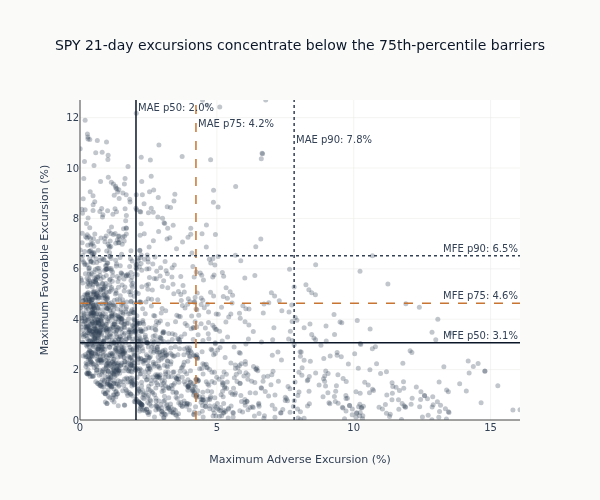

In [16]:
if spy_mfe_mae is not None:
    # House palette with distinct line styles for percentile levels; the
    # yshift staggers the three MAE (vertical) labels so they don't collide
    # along the top axis.
    pctl_styles = [
        (50, COLORS["blue"], "solid", "p50", 0),
        (75, COLORS["copper"], "dash", "p75", -16),
        (90, COLORS["neutral"], "dot", "p90", -32),
    ]

    for pctl, color, dash, label, yshift in pctl_styles:
        mae_val = float(spy_mfe_mae["mae_pct"].quantile(pctl / 100))
        mfe_val = float(spy_mfe_mae["mfe_pct"].quantile(pctl / 100))

        # Horizontal line for MFE threshold (take profit)
        fig.add_hline(
            y=mfe_val,
            line_dash=dash,
            line_color=color,
            line_width=1.5,
            annotation_text=f"MFE {label}: {mfe_val:.1f}%",
            annotation_font_size=10,
        )

        # Vertical line for MAE threshold (stop loss)
        fig.add_vline(
            x=mae_val,
            line_dash=dash,
            line_color=color,
            line_width=1.5,
            annotation_text=f"MAE {label}: {mae_val:.1f}%",
            annotation_font_size=10,
            annotation_yshift=yshift,
        )

    fig.update_layout(
        title="SPY 21-day excursions concentrate below the 75th-percentile barriers",
        xaxis_title="Maximum Adverse Excursion (%)",
        yaxis_title="Maximum Favorable Excursion (%)",
        xaxis_range=[0, x_max],
        yaxis_range=[0, y_max],
        height=500,
        width=600,
        font=dict(size=12),
    )
    fig.show()

## 7. Regime-Conditional Analysis

Barrier effectiveness varies by market regime. High volatility periods
require wider barriers to avoid premature stops.

In [17]:
if spy_mfe_mae is not None and spy_atr is not None:
    # Join MFE/MAE with ATR for regime conditioning
    spy_regime = spy_mfe_mae.join(
        spy_atr.select(["timestamp", "atr_pct"]),
        on="timestamp",
        how="left",
    ).drop_nulls()

    # Define regimes based on ATR percentiles
    low_vol_thresh = spy_regime["atr_pct"].quantile(0.33)
    high_vol_thresh = spy_regime["atr_pct"].quantile(0.67)

    spy_regime = spy_regime.with_columns(
        [
            pl.when(pl.col("atr_pct") <= low_vol_thresh)
            .then(pl.lit("Low Vol"))
            .when(pl.col("atr_pct") >= high_vol_thresh)
            .then(pl.lit("High Vol"))
            .otherwise(pl.lit("Normal"))
            .alias("regime")
        ]
    )

    print("\n=== Regime-Conditional Analysis (SPY) ===")
    for regime in ["Low Vol", "Normal", "High Vol"]:
        regime_data = spy_regime.filter(pl.col("regime") == regime)
        if len(regime_data) > 50:
            print(f"\n{regime} (n={len(regime_data):,}):")
            print(f"  MFE median: {regime_data['mfe_pct'].median():.2f}%")
            print(f"  MAE median: {regime_data['mae_pct'].median():.2f}%")
            print(f"  ATR avg: {regime_data['atr_pct'].mean():.2f}%")


=== Regime-Conditional Analysis (SPY) ===

Low Vol (n=907):
  MFE median: 2.23%
  MAE median: 1.43%
  ATR avg: 0.73%

Normal (n=931):
  MFE median: 2.83%
  MAE median: 1.87%
  ATR avg: 1.08%

High Vol (n=907):
  MFE median: 4.54%
  MAE median: 3.11%
  ATR avg: 1.97%


## 8. Barrier Validation via Hit-Type Analysis

MFE/MAE alone doesn't tell us which barrier hits first.
We validate by running triple-barrier and inspecting hit distributions.

In [18]:
if spy is not None:
    # Test different barrier widths based on percentile analysis
    configs = [
        ("Tight (p50)", 0.02, 0.01),
        ("Medium (p75)", 0.04, 0.02),
        ("Wide (p90)", 0.06, 0.03),
    ]

    print("\n=== Barrier Hit Validation (SPY 21d) ===")

    # triple_barrier_labels requires Datetime timestamps (numpy conversion)
    spy_dt = spy.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))

    for name, tp, sl in configs:
        config = LabelingConfig.triple_barrier(
            upper_barrier=tp,
            lower_barrier=sl,
            max_holding_period=21,
            side=1,
        )

        labels = triple_barrier_labels(spy_dt, config=config, price_col="close")

        # Hit type distribution
        hit_dist = labels.group_by("barrier_hit").len().sort("barrier_hit")

        # Resolution time statistics
        if "resolution_time" in labels.columns:
            avg_res_time = labels["resolution_time"].mean()
        else:
            avg_res_time = None

        print(f"\n{name} (TP={tp:.1%}, SL={sl:.1%}):")
        for row in hit_dist.iter_rows(named=True):
            pct = row["len"] / len(labels) * 100
            print(f"  {row['barrier_hit']}: {row['len']:,} ({pct:.1f}%)")

        if avg_res_time:
            print(f"  Avg resolution: {avg_res_time:.1f} bars")


=== Barrier Hit Validation (SPY 21d) ===

Tight (p50) (TP=2.0%, SL=1.0%):
  lower: 1,390 (50.3%)
  time: 149 (5.4%)
  upper: 1,227 (44.4%)

Medium (p75) (TP=4.0%, SL=2.0%):
  lower: 1,076 (38.9%)
  time: 982 (35.5%)
  upper: 708 (25.6%)

Wide (p90) (TP=6.0%, SL=3.0%):
  lower: 795 (28.7%)
  time: 1,688 (61.0%)
  upper: 283 (10.2%)


## 9. Recommendations Summary

Based on MFE/MAE analysis, the following triple-barrier parameters are justified:

| Dataset      | Horizon | Upper   | Lower   | Rationale                          |
|--------------|---------|---------|---------|-----------------------------------|
| ETF (SPY)    | 21d     | 2xATR   | 1xATR   | Adapts to volatility regime       |
| Crypto (BTC) | 8h      | ~1%     | ~1%     | Near MFE/MAE medians (~0.9%)      |
| Futures (ES) | 21d     | 1.5xATR | 1xATR   | Tighter for institutional flow    |

**Key findings:**

1. ETF daily ATR averages ~1.3% → 2xATR take profit captures majority of moves
2. Crypto 8h MFE/MAE medians are ~0.9% — tight barriers match the funding rate cycle
3. Regime matters: High vol periods have ~2x wider excursions than low vol
4. ATR-scaled barriers recommended for daily; fixed OK for high-frequency

## 10. Export Statistics for Documentation

Save summary statistics for chapter reference.

In [19]:
# Compile summary statistics
summary = {
    "generated_at": datetime.now(UTC).isoformat(),
    "horizons": {
        "etf_spy": 21,
        "crypto_btc": 8,
        "futures_es": 21,
    },
    "datasets": {},
}

if spy_mfe_mae is not None:
    summary["datasets"]["etf_spy_21d"] = {
        "n_observations": len(spy_mfe_mae),
        "mfe_median": float(spy_mfe_mae["mfe_pct"].median()),
        "mfe_75th": float(spy_mfe_mae["mfe_pct"].quantile(0.75)),
        "mfe_90th": float(spy_mfe_mae["mfe_pct"].quantile(0.90)),
        "mae_median": float(spy_mfe_mae["mae_pct"].median()),
        "mae_75th": float(spy_mfe_mae["mae_pct"].quantile(0.75)),
        "mae_90th": float(spy_mfe_mae["mae_pct"].quantile(0.90)),
    }
    if spy_atr is not None:
        summary["datasets"]["etf_spy_21d"]["atr_pct_avg"] = float(spy_atr["atr_pct"].mean())

In [20]:
# BTC and ES summary statistics
if btc_mfe_mae is not None:
    summary["datasets"]["crypto_btc_8h"] = {
        "n_observations": len(btc_mfe_mae),
        "mfe_median": float(btc_mfe_mae["mfe_pct"].median()),
        "mfe_75th": float(btc_mfe_mae["mfe_pct"].quantile(0.75)),
        "mfe_90th": float(btc_mfe_mae["mfe_pct"].quantile(0.90)),
        "mae_median": float(btc_mfe_mae["mae_pct"].median()),
        "mae_75th": float(btc_mfe_mae["mae_pct"].quantile(0.75)),
        "mae_90th": float(btc_mfe_mae["mae_pct"].quantile(0.90)),
    }

if es_mfe_mae is not None:
    summary["datasets"]["futures_es_21d"] = {
        "n_observations": len(es_mfe_mae),
        "mfe_median": float(es_mfe_mae["mfe_pct"].median()),
        "mfe_75th": float(es_mfe_mae["mfe_pct"].quantile(0.75)),
        "mfe_90th": float(es_mfe_mae["mfe_pct"].quantile(0.90)),
        "mae_median": float(es_mfe_mae["mae_pct"].median()),
        "mae_75th": float(es_mfe_mae["mae_pct"].quantile(0.75)),
        "mae_90th": float(es_mfe_mae["mae_pct"].quantile(0.90)),
    }

In [21]:
# Print summary
print("\n=== Summary Statistics for Chapter Reference ===")
for dataset, stats in summary.get("datasets", {}).items():
    print(f"\n{dataset}:")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.2f}")
        else:
            print(f"  {k}: {v}")

# Save to JSON for chapter reference
if SAVE_OUTPUT:
    output_path = OUTPUT_DIR / "mfe_mae_summary.json"
    with open(output_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"\nSaved summary to: {output_path}")


=== Summary Statistics for Chapter Reference ===

etf_spy_21d:
  n_observations: 2745
  mfe_median: 3.06
  mfe_75th: 4.64
  mfe_90th: 6.51
  mae_median: 2.05
  mae_75th: 4.24
  mae_90th: 7.82
  atr_pct_avg: 1.26

crypto_btc_8h:
  n_observations: 43816
  mfe_median: 0.90
  mfe_75th: 1.71
  mfe_90th: 2.93
  mae_median: 0.91
  mae_75th: 1.74
  mae_90th: 3.03

futures_es_21d:
  n_observations: 8446
  mfe_median: 3.16
  mfe_75th: 5.66
  mfe_90th: 18.49
  mae_median: 3.62
  mae_75th: 13.55
  mae_90th: 15.94

Saved summary to: /home/stefan/ml4t/code/07_defining_the_learning_task/output/mfe_mae_summary.json


## 11. Multi-Horizon Excursion Analysis

The manual implementation above analyzes one horizon at a time.
`ml4t-diagnostic` provides `analyze_excursions()` for multi-horizon analysis
in a single call — useful for comparing barrier widths across holding periods.

In [22]:
if spy is not None:
    spy_close = spy["close"]
    horizons = [5, 10, 21, 42]
    result = analyze_excursions(
        spy_close,
        horizons=horizons,
        percentiles=[25, 50, 75, 90],
    )

    print(f"Multi-Horizon Excursion Analysis (SPY) — observations: {result.n_samples:,}")

    multi_horizon_rows = [
        {
            "horizon_days": h,
            "mfe_p50_pct": round(result.get_percentile(h, 50, "mfe") * 100, 2),
            "mfe_p75_pct": round(result.get_percentile(h, 75, "mfe") * 100, 2),
            "mae_p50_pct": round(result.get_percentile(h, 50, "mae") * 100, 2),
            "mae_p75_pct": round(result.get_percentile(h, 75, "mae") * 100, 2),
        }
        for h in horizons
    ]
    multi_horizon_df = pl.DataFrame(multi_horizon_rows)
    display(multi_horizon_df)

Multi-Horizon Excursion Analysis (SPY) — observations: 2,724


horizon_days,mfe_p50_pct,mfe_p75_pct,mae_p50_pct,mae_p75_pct
i64,f64,f64,f64,f64
5,0.95,1.79,-0.41,0.0
10,1.59,2.84,-0.83,0.0
21,2.75,4.41,-1.39,-0.26
42,4.62,6.9,-2.08,-0.53


Two conventions appear in the table above. The manual MFE/MAE block (Section 3)
clips both excursions to be non-negative - adverse moves report as positive
percentages. The `analyze_excursions` library reports adverse excursions as
*signed* deviations (negative when the price drops below entry), which is why
`mae_p50_pct` shows negative values. Both conventions are valid; barrier
calibration only needs the magnitude. The two are close but not identical: the
library measures excursions on close prices, while the manual block uses
intraday high/low, so the manual magnitudes run wider (quantified in the
comparison below).

In [23]:
# Compare manual single-horizon vs library multi-horizon
if spy_mfe_mae is not None:
    print("--- Manual vs Library (21d horizon) ---")
    manual_mfe_50 = spy_mfe_mae["mfe_pct"].quantile(0.5)
    library_mfe_50 = result.get_percentile(21, 50, "mfe") * 100
    manual_mae_50 = spy_mfe_mae["mae_pct"].quantile(0.5)
    library_mae_50_abs = abs(result.get_percentile(21, 50, "mae") * 100)
    print(f"Manual  MFE p50 (uses high):  {manual_mfe_50:.2f}%")
    print(f"Library MFE p50 (uses close): {library_mfe_50:.2f}%")
    print(f"Manual  |MAE| p50 (uses low):   {manual_mae_50:.2f}%")
    print(f"Library |MAE| p50 (uses close): {library_mae_50_abs:.2f}%")
    print(
        "\nManual uses high/low prices for intraday extremes; the library uses "
        "close prices only. High/low captures wider excursions and is the "
        "more appropriate reference for barrier-width selection."
    )

--- Manual vs Library (21d horizon) ---
Manual  MFE p50 (uses high):  3.06%
Library MFE p50 (uses close): 2.75%
Manual  |MAE| p50 (uses low):   2.05%
Library |MAE| p50 (uses close): 1.39%

Manual uses high/low prices for intraday extremes; the library uses close prices only. High/low captures wider excursions and is the more appropriate reference for barrier-width selection.


## Summary

This notebook provides empirical justification for triple-barrier parameters:

1. **Vectorized MFE/MAE**: Efficient computation using Polars horizontal operations
2. **ATR**: True range with Wilder smoothing
3. **Non-negative excursions**: MFE/MAE clipped at 0 by definition
4. **Regime conditioning**: High-vol periods require wider barriers
5. **Validation via hit-types**: Barrier widths validated by hit distribution

### Key Results

- **ETF (SPY)**: 2xATR take profit, 1xATR stop loss for 21-day horizon (ATR avg 1.26%)
- **Crypto (BTC)**: ~1% fixed barriers for 8-hour funding rate cycle (MFE/MAE medians ~0.9%)
- **Volatility scaling**: Required for daily strategies; less critical for high-frequency

### Production Usage

Use the exported `mfe_mae_summary.json` for chapter references.
For custom calibration, run this notebook with your specific asset and horizon.